## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 수익성 원자료 검증 EDA

`수익성_전체통합_1994_2025.csv` — **원자료가 정상인가**

| 단계 | 질문 |
|---|---|
| 0 | 이 파일에 무엇이 들어있는가 |
| 1 | 영업이익률을 원항목으로 재현할 수 있는가 |
| 2 | 이자보상비율이 안정성 파일과 맞는가 |
| 3 | 부호가 경제적으로 모순되지 않는가 |
| 4 | ICR의 꼬리가 얼마나 두꺼운가 |
| 5 | 표본 구성이 바뀐 흔적이 있는가 |

## 준비

In [2]:
import pandas as pd, numpy as np, warnings
import matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
          "Pretendard", "Noto Sans CJK KR", "Noto Sans CJK JP"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        print(f"폰트: {f}")
        break
    except Exception:
        continue
mpl.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 100,
                     "axes.grid": True, "grid.alpha": .18,
                     "axes.spines.top": False, "axes.spines.right": False})

INK, WARN, OK, GREY = "#16202B", "#C1682E", "#2E6B5E", "#98A2AA"
PAL = [INK, OK, WARN, "#6B7783", "#A8B2B8"]

def ok_bad(cond, a, b):
    display(Markdown(f"**{'✅ 정상' if cond else '⚠️ 확인필요'}** — {a if cond else b}"))

def paint(df, col="판정", good="정상"):
    return df.style.map(
        lambda x: "background-color:#E4EFEB;color:#1F6152" if x == good
                  else "background-color:#F6E7E4;color:#8E3226", subset=[col])

폰트: Malgun Gothic


In [3]:
d = pd.read_csv(str(INTERIM / "ISTANS 수익성" / "수익성_전체통합_1994_2025.csv"), encoding="utf-8-sig")
try:
    stab = pd.read_csv(str(INTERIM / "ISTANS 안정성" / "안정성_전체통합_1994_2025.csv"), encoding="utf-8-sig")
    print("안정성 파일 로드 — 교차검증 수행")
except FileNotFoundError:
    stab = None
    print("안정성 파일 없음 — 2단계 생략")

print(f"{len(d)}행 × {d.shape[1]}열   업종 {d['업종코드'].nunique()}개   "
      f"연도 {d['연도'].min()}~{d['연도'].max()}")
d.head(3)

안정성 파일 로드 — 교차검증 수행
1280행 × 8열   업종 40개   연도 1994~2025


,업종코드,업종,연도,매출액,영업이익,당기순이익,영업이익률,이자보상비율
0,I3101,의약,1994,2569.0,395.0,55.0,15.4,276.3
1,I3101,의약,1995,3034.0,435.0,79.0,14.3,241.1
2,I3101,의약,1996,3409.0,460.0,99.0,13.5,233.7


---
## 0단계 · 기본 구조

In [4]:
cnt = d.groupby("연도").size()
ok_bad(cnt.nunique() == 1, f"연도마다 {cnt.iloc[0]}개 업종 — 완전 균형", "불균형")
ok_bad(d.duplicated(["업종코드", "연도"]).sum() == 0, "업종×연도 중복 없음", "중복 있음")
ok_bad(d.isna().sum().sum() == 0, "결측 없음", f"결측 {d.isna().sum().sum()}건")

display(d[["매출액", "영업이익", "당기순이익", "영업이익률", "이자보상비율"]]
          .describe().T[["mean", "std", "min", "50%", "max"]].round(1)
          .rename(columns={"mean":"평균","std":"표준편차","min":"최소",
                           "50%":"중앙","max":"최대"}))

**✅ 정상** — 연도마다 40개 업종 — 완전 균형

**✅ 정상** — 업종×연도 중복 없음

**✅ 정상** — 결측 없음

,평균,표준편차,최소,중앙,최대
매출액,25529.6,44254.0,11.0,7877.5,366650.0
영업이익,1628.6,3670.9,-10653.0,492.0,45479.0
당기순이익,1276.9,3509.7,-8292.0,277.5,42456.0
영업이익률,6.7,5.9,-16.7,5.8,38.8
이자보상비율,975.4,4615.9,-2655.1,368.6,104013.8


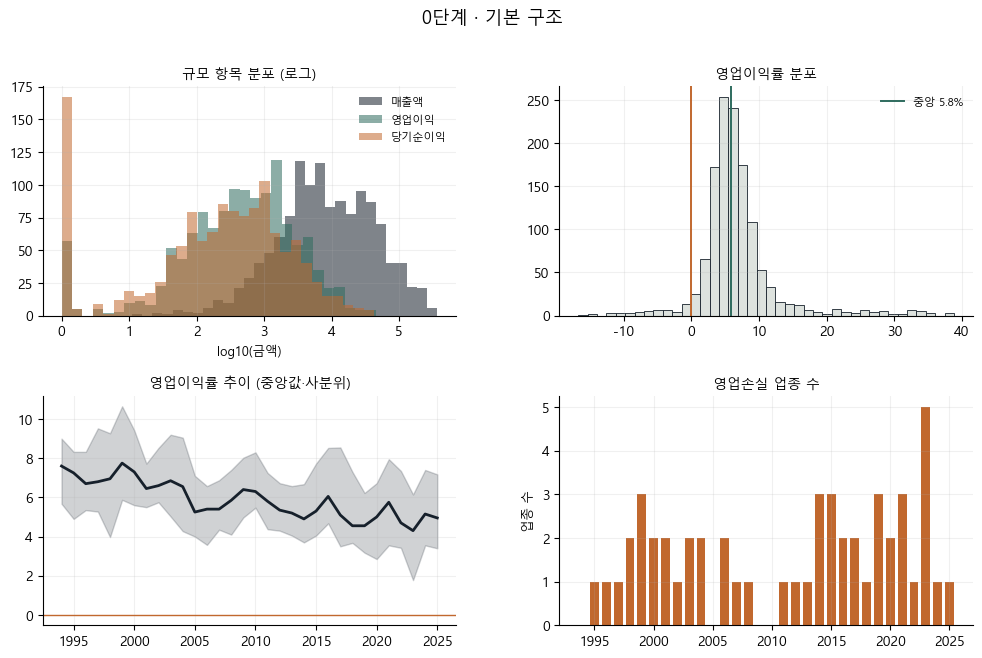

In [5]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, 0])
for c, col in zip(["매출액", "영업이익", "당기순이익"], PAL):
    ax.hist(np.log10(d[c].clip(lower=1)), bins=30, alpha=.55, label=c, color=col)
ax.set_xlabel("log10(금액)", fontsize=9); ax.legend(frameon=False, fontsize=8)
ax.set_title("규모 항목 분포 (로그)", fontsize=10)

ax = fig.add_subplot(gs[0, 1])
ax.hist(d["영업이익률"], bins=40, color="#DDE2DE", edgecolor=INK, linewidth=.6)
ax.axvline(0, color=WARN, lw=1.4)
ax.axvline(d["영업이익률"].median(), color=OK, lw=1.4,
           label=f"중앙 {d['영업이익률'].median():.1f}%")
ax.legend(frameon=False, fontsize=8)
ax.set_title("영업이익률 분포", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
g = d.groupby("연도")["영업이익률"]
ax.fill_between(g.median().index, g.quantile(.25), g.quantile(.75),
                alpha=.2, color=INK)
ax.plot(g.median().index, g.median(), lw=2, color=INK)
ax.axhline(0, color=WARN, lw=1)
ax.set_title("영업이익률 추이 (중앙값·사분위)", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
neg = d.groupby("연도").apply(lambda x: (x["영업이익"] < 0).sum())
ax.bar(neg.index, neg.values, color=WARN, width=.75)
ax.set_ylabel("업종 수", fontsize=9)
ax.set_title("영업손실 업종 수", fontsize=10)

plt.suptitle("0단계 · 기본 구조", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 1단계 · 영업이익률 정의 검산

In [6]:
TOL = 0.15
cands = [("영업이익/매출액", d["영업이익"]/d["매출액"]*100),
         ("당기순이익/매출액", d["당기순이익"]/d["매출액"]*100)]
rows = []
for lab, calc in cands:
    diff = (d["영업이익률"] - calc).abs()
    rows.append({"후보 공식": lab, "일치율(%)": round((diff < TOL).mean()*100, 2),
                 "중앙오차": round(diff.median(), 4)})
R1 = pd.DataFrame(rows)
R1["판정"] = np.where(R1["일치율(%)"] > 90, "정상", "불일치")
display(paint(R1, good="정상"))

calc = d["영업이익"]/d["매출액"]*100
diff = (d["영업이익률"] - calc).abs()
ok_bad((diff < TOL).mean() > .95,
       f"영업이익/매출액 로 확정 (일치율 {(diff<TOL).mean()*100:.1f}%)", "재현 안 됨")

off = d[diff >= TOL].assign(계산값=calc[diff >= TOL].round(2),
                            오차=diff[diff >= TOL].round(3))
display(Markdown(f"### 불일치 {len(off)}건 — 반올림 수준인가"))
display(off[["업종", "연도", "영업이익률", "계산값", "오차"]]
        .nlargest(8, "오차").reset_index(drop=True))

,후보 공식,일치율(%),중앙오차,판정
0,영업이익/매출액,97.970000,0.026600,정상
1,당기순이익/매출액,2.970000,2.274300,불일치


**✅ 정상** — 영업이익/매출액 로 확정 (일치율 98.0%)

### 불일치 26건 — 반올림 수준인가

,업종,연도,영업이익률,계산값,오차
0,컴퓨터,1994,3.2,0.00,3.200
1,철도,1994,9.9,11.54,1.638
2,철도,1996,5.2,6.12,0.922
3,철도,1998,2.5,3.33,0.833
4,컴퓨터,1996,2.9,2.22,0.678
5,컴퓨터,1998,3.6,2.94,0.659
6,기타 수송장비,1995,-6.8,-6.17,0.627
7,컴퓨터,1997,2.4,2.94,0.541


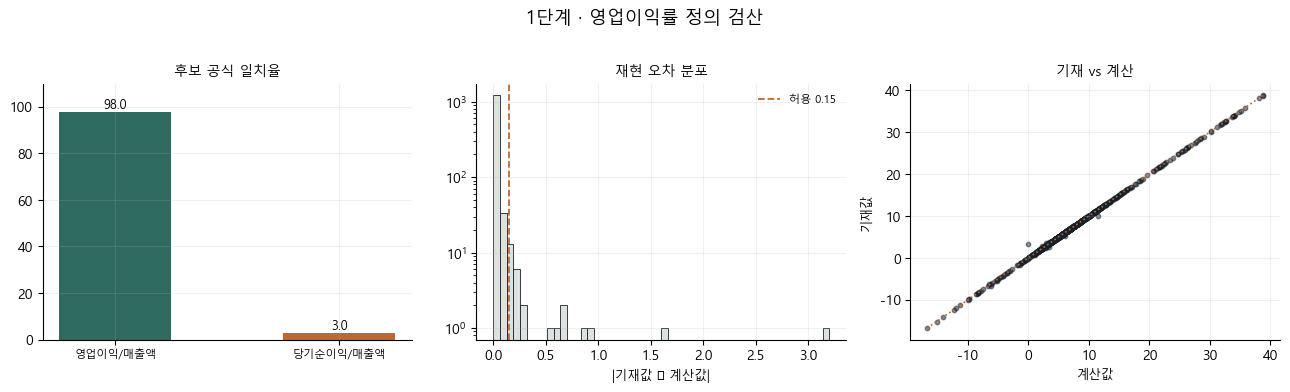

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.bar(R1["후보 공식"], R1["일치율(%)"], width=.5,
       color=[OK if v > 90 else WARN for v in R1["일치율(%)"]])
for i, v in enumerate(R1["일치율(%)"]):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 110); ax.tick_params(axis="x", labelsize=8)
ax.set_title("후보 공식 일치율", fontsize=10)

ax = axes[1]
ax.hist(diff, bins=50, color="#DDE2DE", edgecolor=INK, linewidth=.6)
ax.axvline(TOL, ls="--", lw=1.3, color=WARN, label=f"허용 {TOL}")
ax.set_yscale("log"); ax.legend(frameon=False, fontsize=8)
ax.set_xlabel("|기재값 − 계산값|", fontsize=9)
ax.set_title("재현 오차 분포", fontsize=10)

ax = axes[2]
ax.scatter(calc, d["영업이익률"], s=10, color=INK, alpha=.5)
lim = [d["영업이익률"].min(), d["영업이익률"].max()]
ax.plot(lim, lim, ls=":", color=WARN, lw=1.2)
ax.set_xlabel("계산값", fontsize=9); ax.set_ylabel("기재값", fontsize=9)
ax.set_title("기재 vs 계산", fontsize=10)

plt.suptitle("1단계 · 영업이익률 정의 검산", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 2단계 · 이자보상비율 교차검증

안정성 파일의 `이자비용`으로 ICR을 역산해 기재값과 대조한다.
**이자비용이 정수로 반올림돼 있으면** 작은 값에서 오차가 폭발한다.

In [8]:
if stab is None:
    display(Markdown("안정성 파일이 없어 생략합니다."))
else:
    m = d.merge(stab[["업종코드", "연도", "이자비용"]], on=["업종코드", "연도"], how="left")
    m["계산ICR"] = np.where(m["이자비용"] > 0, m["영업이익"]/m["이자비용"]*100, np.nan)
    m["오차"] = (m["이자보상비율"] - m["계산ICR"]).abs()
    rate = (m["오차"] < 1.0).mean()*100

    ok_bad(rate > 95, f"일치율 {rate:.1f}% — 같은 원장",
           f"일치율 {rate:.1f}% — 재현 불가")

    display(Markdown("### 오차가 큰 관측 — 이자비용 크기와 함께"))
    display(m.nlargest(8, "오차")[["업종", "연도", "영업이익", "이자비용",
                                  "이자보상비율", "계산ICR", "오차"]]
            .round(1).reset_index(drop=True))

    grp = m.assign(이자비용구간=pd.cut(m["이자비용"],
                   [0, 10, 100, 1000, 1e9],
                   labels=["≤10", "10~100", "100~1000", ">1000"]))
    T = grp.groupby("이자비용구간", observed=True).agg(
        관측수=("오차", "size"), 중앙오차=("오차", "median"),
        일치율=("오차", lambda s: (s < 1).mean()*100)).round(2)
    display(Markdown("### 이자비용 크기별 재현 정확도"))
    display(T)
    display(Markdown("> 이자비용이 작을수록 재현이 어긋난다 = 반올림 때문. "
                     "**ICR은 기재값을 쓰고 역산하지 않는다.**"))

**⚠️ 확인필요** — 일치율 62.4% — 재현 불가

### 오차가 큰 관측 — 이자비용 크기와 함께

,업종,연도,영업이익,이자비용,이자보상비율,계산ICR,오차
0,담배,2000,432.0,1.0,83279.4,43200.0,40079.4
1,담배,1999,267.0,1.0,50239.3,26700.0,23539.3
2,담배,1995,255.0,1.0,42448.4,25500.0,16948.4
3,담배,1997,217.0,1.0,17480.1,21700.0,4219.9
4,담배,2016,1433.0,5.0,30658.3,28660.0,1998.3
5,담배,2015,1520.0,5.0,28984.0,30400.0,1416.0
6,담배,2009,1119.0,6.0,17543.1,18650.0,1106.9
7,담배,2001,469.0,4.0,12731.0,11725.0,1006.0


### 이자비용 크기별 재현 정확도

,관측수,중앙오차,일치율
이자비용구간,,,
≤10,67,17.30,4.48
10~100,452,1.82,31.64
100~1000,681,0.27,84.58
>1000,78,0.06,98.72


> 이자비용이 작을수록 재현이 어긋난다 = 반올림 때문. **ICR은 기재값을 쓰고 역산하지 않는다.**

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


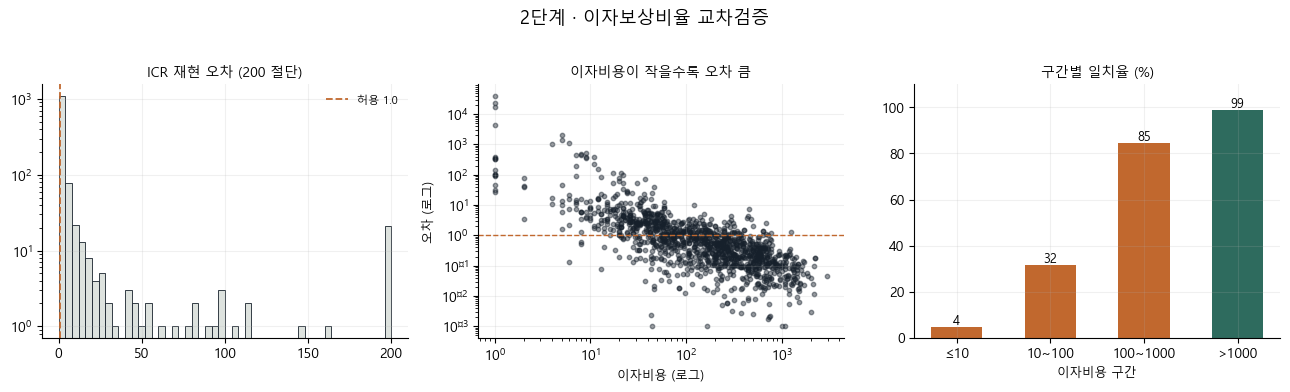

In [9]:
if stab is not None:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

    ax = axes[0]
    ax.hist(m["오차"].clip(upper=200), bins=50, color="#DDE2DE",
            edgecolor=INK, linewidth=.6)
    ax.axvline(1, ls="--", lw=1.3, color=WARN, label="허용 1.0")
    ax.set_yscale("log"); ax.legend(frameon=False, fontsize=8)
    ax.set_title("ICR 재현 오차 (200 절단)", fontsize=10)

    ax = axes[1]
    ax.scatter(m["이자비용"].clip(lower=.5), m["오차"].clip(lower=1e-3),
               s=10, color=INK, alpha=.45)
    ax.axhline(1, ls="--", lw=1, color=WARN)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("이자비용 (로그)", fontsize=9); ax.set_ylabel("오차 (로그)", fontsize=9)
    ax.set_title("이자비용이 작을수록 오차 큼", fontsize=10)

    ax = axes[2]
    ax.bar(T.index.astype(str), T["일치율"], width=.55,
           color=[OK if v > 95 else WARN for v in T["일치율"]])
    for i, v in enumerate(T["일치율"]):
        ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 110); ax.set_xlabel("이자비용 구간", fontsize=9)
    ax.set_title("구간별 일치율 (%)", fontsize=10)

    plt.suptitle("2단계 · 이자보상비율 교차검증", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

---
## 3단계 · 부호 정합성

In [10]:
rows = [
    ("매출액 ≤ 0", int((d["매출액"] <= 0).sum()), "불가능"),
    ("영업이익 < 0", int((d["영업이익"] < 0).sum()), "정상 (영업손실)"),
    ("당기순이익 < 0", int((d["당기순이익"] < 0).sum()), "정상"),
    ("ICR < 0", int((d["이자보상비율"] < 0).sum()), "정상 (손실의 결과)"),
    ("영업이익<0 인데 ICR>0", int(((d["영업이익"] < 0) & (d["이자보상비율"] > 0)).sum()),
     "모순"),
    ("당기순이익 > 영업이익", int((d["당기순이익"] > d["영업이익"]).sum()), "영업외수익"),
]
R3 = pd.DataFrame(rows, columns=["조건", "건수", "성격"])
display(R3)

ok_bad((d["매출액"] <= 0).sum() == 0, "매출액 모두 양수", "매출액 0 이하 존재")
ok_bad(((d["영업이익"] < 0) & (d["이자보상비율"] > 0)).sum() == 0,
       "부호 모순 없음 — 영업손실이면 ICR도 음수", "부호 모순 발견")

ex = d[(d["영업이익"] > 0) & (d["당기순이익"] > d["영업이익"]*3)]
display(Markdown(f"### 당기순이익이 영업이익의 3배 초과 — {len(ex)}건"))
display(ex.nlargest(6, "당기순이익")[["업종", "연도", "영업이익", "당기순이익"]]
        .reset_index(drop=True))

,조건,건수,성격
0,매출액 ≤ 0,0,불가능
1,영업이익 < 0,51,정상 (영업손실)
2,당기순이익 < 0,151,정상
3,ICR < 0,52,정상 (손실의 결과)
4,영업이익<0 인데 ICR>0,0,모순
5,당기순이익 > 영업이익,156,영업외수익


**✅ 정상** — 매출액 모두 양수

**✅ 정상** — 부호 모순 없음 — 영업손실이면 ICR도 음수

### 당기순이익이 영업이익의 3배 초과 — 8건

,업종,연도,영업이익,당기순이익
0,디스플레이,2024,692.0,3344.0
1,전지,2012,359.0,2800.0
2,디스플레이,2020,326.0,1315.0
3,가전,2000,242.0,876.0
4,조선,2005,17.0,358.0
5,기타 수송장비,2020,40.0,180.0


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


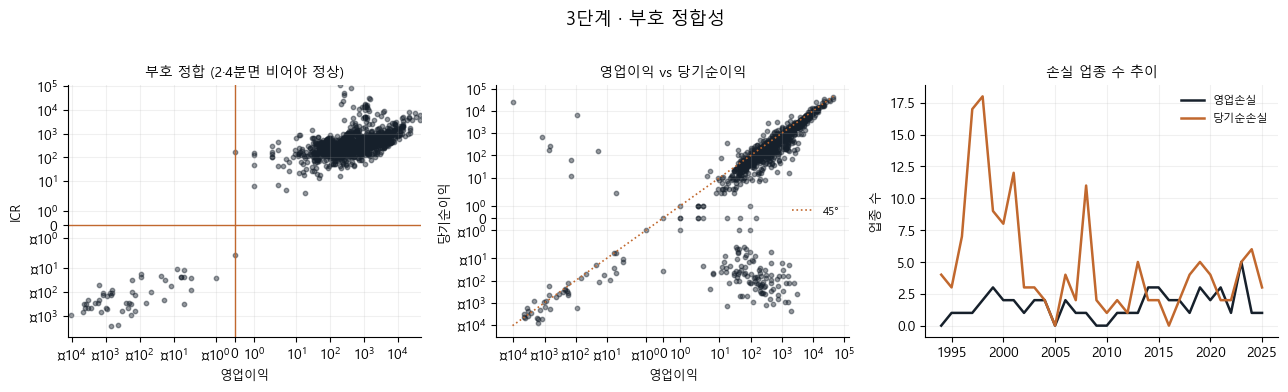

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.scatter(d["영업이익"], d["이자보상비율"], s=10, color=INK, alpha=.45)
ax.axhline(0, color=WARN, lw=1); ax.axvline(0, color=WARN, lw=1)
ax.set_xscale("symlog"); ax.set_yscale("symlog")
ax.set_xlabel("영업이익", fontsize=9); ax.set_ylabel("ICR", fontsize=9)
ax.set_title("부호 정합 (2·4분면 비어야 정상)", fontsize=10)

ax = axes[1]
ax.scatter(d["영업이익"], d["당기순이익"], s=10, color=INK, alpha=.45)
lim = [d["영업이익"].min(), d["영업이익"].max()]
ax.plot(lim, lim, ls=":", color=WARN, lw=1.2, label="45°")
ax.set_xscale("symlog"); ax.set_yscale("symlog"); ax.legend(frameon=False, fontsize=8)
ax.set_xlabel("영업이익", fontsize=9); ax.set_ylabel("당기순이익", fontsize=9)
ax.set_title("영업이익 vs 당기순이익", fontsize=10)

ax = axes[2]
neg = d.groupby("연도").apply(
    lambda x: pd.Series({"영업손실": (x["영업이익"] < 0).sum(),
                         "당기순손실": (x["당기순이익"] < 0).sum()}))
ax.plot(neg.index, neg["영업손실"], lw=1.8, color=INK, label="영업손실")
ax.plot(neg.index, neg["당기순손실"], lw=1.8, color=WARN, label="당기순손실")
ax.legend(frameon=False, fontsize=8); ax.set_ylabel("업종 수", fontsize=9)
ax.set_title("손실 업종 수 추이", fontsize=10)

plt.suptitle("3단계 · 부호 정합성", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 4단계 · ICR 꼬리 두께

변환 방식(winsorize·asinh 등)이 회귀 결과를 좌우할 만큼 꼬리가 두꺼운지 본다.

In [12]:
icr = d["이자보상비율"]
T4 = pd.DataFrame([
    ("1분위",  icr.quantile(.01)),
    ("중앙값", icr.median()),
    ("99분위", icr.quantile(.99)),
    ("최대값", icr.max()),
], columns=["통계량", "값"]).round(1)
T4["중앙값 대비"] = (T4["값"]/icr.median()).round(1)
display(T4)

display(Markdown("### ICR 상위 8 — 어느 업종이 꼬리를 만드는가"))
display(d.nlargest(8, "이자보상비율")[["업종", "연도", "이자보상비율", "영업이익률"]]
        .round(1).reset_index(drop=True))

top = d.nlargest(20, "이자보상비율")["업종"].value_counts()
ok_bad(top.iloc[0] < 10, "상위 20에 특정 업종 집중 없음",
       f"상위 20 중 **{top.index[0]}**가 {top.iloc[0]}건 — 한 업종이 꼬리를 지배")

d["ICR_w1"] = icr.clip(*icr.quantile([.01, .99]))
d["ICR_asinh"] = np.arcsinh(icr)
display(Markdown("### 변환 후보 비교"))
display(d[["이자보상비율", "ICR_w1", "ICR_asinh"]].describe().T
          .round(2)[["min", "50%", "max", "std"]])

,통계량,값,중앙값 대비
0,1분위,-462.9,-1.3
1,중앙값,368.6,1.0
2,99분위,13186.1,35.8
3,최대값,104013.8,282.2


### ICR 상위 8 — 어느 업종이 꼬리를 만드는가

,업종,연도,이자보상비율,영업이익률
0,담배,1994,104013.8,6.4
1,담배,2000,83279.4,23.4
2,담배,1999,50239.3,16.7
3,담배,1995,42448.4,7.5
4,담배,2016,30658.3,35.8
5,담배,2015,28984.0,38.7
6,담배,1996,24043.5,5.8
7,담배,2009,17543.1,32.3


**⚠️ 확인필요** — 상위 20 중 **담배**가 20건 — 한 업종이 꼬리를 지배

### 변환 후보 비교

,min,50%,max,std
이자보상비율,-2655.10,368.6,104013.80,4615.94
ICR_w1,-462.93,368.6,13186.10,1778.70
ICR_asinh,-8.58,6.6,12.25,2.67


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


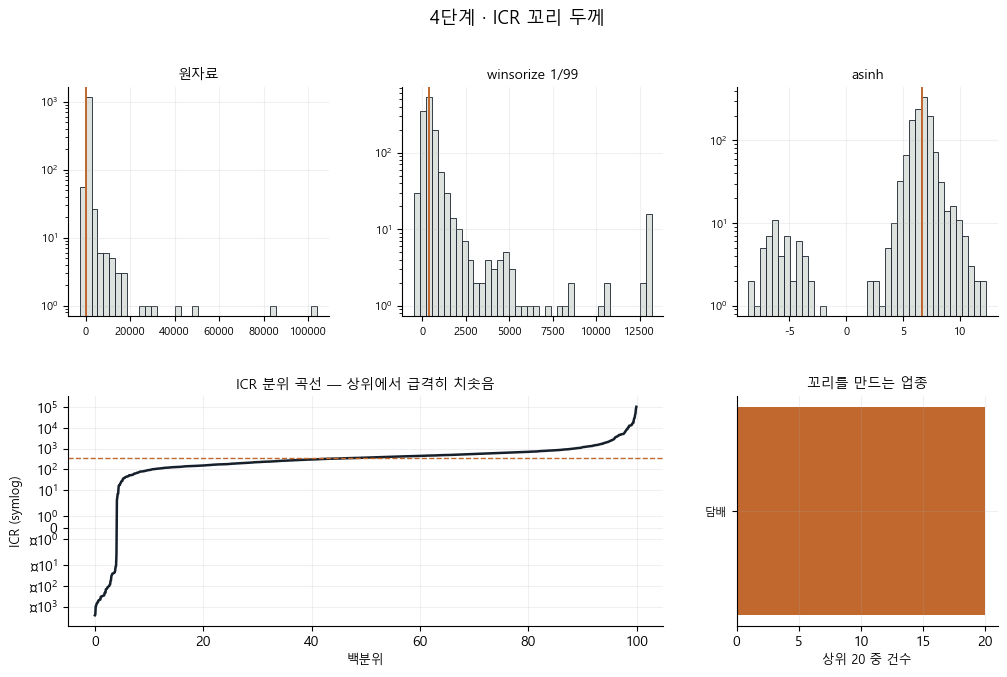

In [13]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 3, hspace=.35, wspace=.28)

for k, (c, t) in enumerate([("이자보상비율", "원자료"),
                            ("ICR_w1", "winsorize 1/99"),
                            ("ICR_asinh", "asinh")]):
    ax = fig.add_subplot(gs[0, k])
    ax.hist(d[c], bins=40, color="#DDE2DE", edgecolor=INK, linewidth=.6)
    ax.axvline(d[c].median(), color=WARN, lw=1.4)
    ax.set_yscale("log"); ax.set_title(t, fontsize=10); ax.tick_params(labelsize=8)

ax = fig.add_subplot(gs[1, :2])
srt = icr.sort_values().values
ax.plot(np.arange(len(srt))/len(srt)*100, srt, lw=1.8, color=INK)
ax.set_yscale("symlog"); ax.axhline(icr.median(), ls="--", lw=1, color=WARN)
ax.set_xlabel("백분위", fontsize=9); ax.set_ylabel("ICR (symlog)", fontsize=9)
ax.set_title("ICR 분위 곡선 — 상위에서 급격히 치솟음", fontsize=10)

ax = fig.add_subplot(gs[1, 2])
tv = d.nlargest(20, "이자보상비율")["업종"].value_counts().head(5)
ax.barh(tv.index[::-1], tv.values[::-1], color=WARN, height=.6)
ax.set_xlabel("상위 20 중 건수", fontsize=9)
ax.set_title("꼬리를 만드는 업종", fontsize=10); ax.tick_params(axis="y", labelsize=8)

plt.suptitle("4단계 · ICR 꼬리 두께", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 5단계 · 표본 연속성

In [14]:
JUMP = 50
d = d.sort_values(["업종코드", "연도"])
d["매출증가율"] = d.groupby("업종코드")["매출액"].pct_change()*100
j = d[d["매출증가율"].abs() > JUMP].dropna(subset=["매출증가율"])

display(Markdown(f"**매출액 ±{JUMP}% 초과: {len(j)}건**"))
display(j.nlargest(8, "매출증가율")[["업종", "연도", "매출액", "매출증가율"]]
        .round(1).reset_index(drop=True))

recent = j[j["연도"] >= 2015]
display(Markdown(f"### 분석기간(2015~) {len(recent)}건 — 실제 산업 변동인가"))
display(recent[["업종", "연도", "매출증가율"]].round(1).reset_index(drop=True))
ok_bad(len(recent) <= 10, "분석기간 급변이 제한적 — 대부분 설명 가능한 산업 사이클",
       "분석기간 급변 과다")

**매출액 ±50% 초과: 32건**

,업종,연도,매출액,매출증가율
0,디스플레이,1999,2543.0,848.9
1,철도,1999,566.0,843.3
2,컴퓨터,1995,40.0,263.6
3,컴퓨터,1999,173.0,154.4
4,기타 수송장비,1996,177.0,118.5
5,디스플레이,2012,56086.0,97.5
6,석유정제,2008,119938.0,92.4
7,디스플레이,2003,7799.0,86.0


### 분석기간(2015~) 7건 — 실제 산업 변동인가

,업종,연도,매출증가율
0,반도체,2017,50.7
1,반도체,2024,54.7
2,컴퓨터,2019,58.6
3,전지,2021,78.9
4,전지,2022,66.4
5,항공,2023,72.8
6,석유정제,2022,63.5


**✅ 정상** — 분석기간 급변이 제한적 — 대부분 설명 가능한 산업 사이클

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


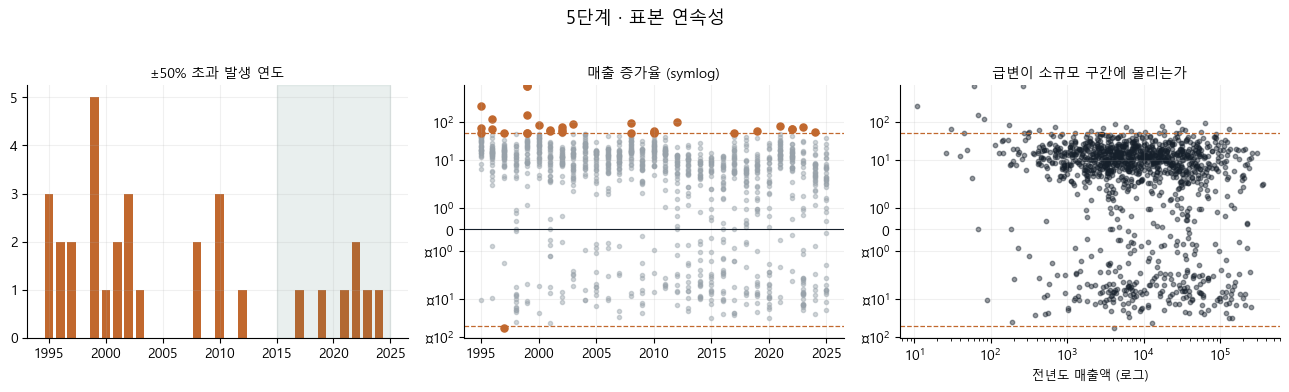

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
vc = j["연도"].value_counts().sort_index()
ax.bar(vc.index, vc.values, color=WARN, width=.75)
ax.axvspan(2015, d["연도"].max(), color=OK, alpha=.1)
ax.set_title(f"±{JUMP}% 초과 발생 연도", fontsize=10)

ax = axes[1]
ax.scatter(d["연도"], d["매출증가율"], s=9, color=GREY, alpha=.45)
ax.scatter(j["연도"], j["매출증가율"], s=26, color=WARN)
ax.axhline(JUMP, ls="--", lw=.9, color=WARN); ax.axhline(-JUMP, ls="--", lw=.9, color=WARN)
ax.axhline(0, color=INK, lw=.8); ax.set_yscale("symlog")
ax.set_title("매출 증가율 (symlog)", fontsize=10)

ax = axes[2]
prev = d.groupby("업종코드")["매출액"].shift(1)
ax.scatter(prev, d["매출증가율"], s=10, color=INK, alpha=.45)
ax.axhline(JUMP, ls="--", lw=.9, color=WARN); ax.axhline(-JUMP, ls="--", lw=.9, color=WARN)
ax.set_xscale("log"); ax.set_yscale("symlog")
ax.set_xlabel("전년도 매출액 (로그)", fontsize=9)
ax.set_title("급변이 소규모 구간에 몰리는가", fontsize=10)

plt.suptitle("5단계 · 표본 연속성", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 종합

In [16]:
r = d[d["연도"] >= 2015]
icr_rate = (m["오차"] < 1.0).mean()*100 if stab is not None else np.nan
S = pd.DataFrame([
    ("0 기본구조", f"{len(d)}행, 40업종×32년 완전균형, 결측 0", "정상"),
    ("1 영업이익률", f"영업이익/매출액 일치율 {(diff<TOL).mean()*100:.1f}%", "정상"),
    ("2 ICR 교차검증",
     f"안정성 이자비용으로 역산 시 일치율 {icr_rate:.1f}% (반올림 탓)"
     if stab is not None else "안정성 파일 없음", "확인필요"),
    ("3 부호", "매출 양수, 부호 모순 0건", "정상"),
    ("4 꼬리", f"최대값이 중앙값의 {icr.max()/icr.median():.0f}배", "확인필요"),
    ("5 연속성", f"매출 급변 {len(j)}건, 분석기간 {len(recent)}건", "정상"),
], columns=["단계", "내용", "판정"])
display(paint(S))

display(Markdown(f"""
### 분석기간(2015~2025) 요약
- 관측치 **{len(r)}행**, 결측 **{r.isna().sum().sum()}건**
- 영업손실 **{int((r['영업이익']<0).sum())}건**, ICR 음수 **{int((r['이자보상비율']<0).sum())}건**
- ICR 중앙 **{r['이자보상비율'].median():.1f}**, 최대 **{r['이자보상비율'].max():.1f}**

### 처리가 필요한 것
1. **ICR은 기재값을 쓰고 역산하지 않는다** — 이자비용 반올림으로 재현 불가
2. **ICR 변환 방식을 결과 보기 전에 확정** — 꼬리가 두꺼워 선택이 회귀를 좌우
3. 음수 ICR은 실제 영업손실이므로 삭제하지 않는다
4. 담배가 꼬리를 지배하므로 포함/제외 강건성 검정 필요
"""))

,단계,내용,판정
0,0 기본구조,"1280행, 40업종×32년 완전균형, 결측 0",정상
1,1 영업이익률,영업이익/매출액 일치율 98.0%,정상
2,2 ICR 교차검증,안정성 이자비용으로 역산 시 일치율 62.4% (반올림 탓),확인필요
3,3 부호,"매출 양수, 부호 모순 0건",정상
4,4 꼬리,최대값이 중앙값의 282배,확인필요
5,5 연속성,"매출 급변 32건, 분석기간 7건",정상



### 분석기간(2015~2025) 요약
- 관측치 **440행**, 결측 **0건**
- 영업손실 **24건**, ICR 음수 **25건**
- ICR 중앙 **469.2**, 최대 **30658.3**

### 처리가 필요한 것
1. **ICR은 기재값을 쓰고 역산하지 않는다** — 이자비용 반올림으로 재현 불가
2. **ICR 변환 방식을 결과 보기 전에 확정** — 꼬리가 두꺼워 선택이 회귀를 좌우
3. 음수 ICR은 실제 영업손실이므로 삭제하지 않는다
4. 담배가 꼬리를 지배하므로 포함/제외 강건성 검정 필요
